In [ ]:
import random
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [ ]:
def generate_cities(n_cities, n_regions, seed):
    random.seed(seed)
    cities = []
    city_regions = []

    grid = 3
    per_region = n_cities // n_regions
    remainder = n_cities - per_region * n_regions

    for row in range(grid):
        for col in range(grid):
            region_idx = row * grid + col
            count = per_region + (1 if region_idx < remainder else 0)

            x_min, x_max = col / grid, (col + 1) / grid
            y_min, y_max = row / grid, (row + 1) / grid

            for _ in range(count):
                x = random.uniform(x_min, x_max)
                y = random.uniform(y_min, y_max)
                cities.append((x, y))
                city_regions.append(region_idx)

    return cities, city_regions

In [ ]:
def plot_cities(cities, city_regions):
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'black']

    plt.figure(figsize=(8, 6))

    for region in range(9):
        xs = [cities[i][0] for i in range(len(cities)) if city_regions[i] == region]
        ys = [cities[i][1] for i in range(len(cities)) if city_regions[i] == region]

        plt.scatter(xs, ys, s=18, color=colors[region], label=f'Region {region + 1}')

    plt.title('Cities by region')
    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.axvline(x=1/3, linestyle='--', linewidth=1)
    plt.axvline(x=2/3, linestyle='--', linewidth=1)
    plt.axhline(y=1/3, linestyle='--', linewidth=1)
    plt.axhline(y=2/3, linestyle='--', linewidth=1)

    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.savefig('region.png', dpi=200, bbox_inches='tight')
    plt.show()

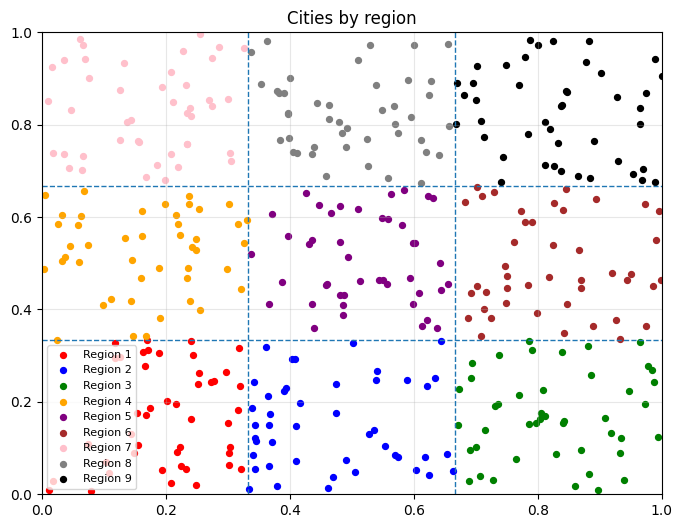

[(0.3186780906297498, 0.3159424956864498), (0.018850455908936227, 0.028290665052973875), (0.2784996260431498, 0.24532332968950776), (0.2232434671467403, 0.10271215252971473), (0.20198138855948747, 0.20226724454694595), (0.1937346723706677, 0.05279429008493519), (0.1435565467637562, 0.13117727340179045), (0.24100402707915528, 0.33160652098324755), (0.31646515769774786, 0.18139234914310692), (0.14828472957528452, 0.08941358054977602), (0.01197477646428587, 0.009148285696939668), (0.15496462069910402, 0.10615504261789246), (0.12667164063357053, 0.29726315260942915), (0.1752509230486761, 0.18683678700883294), (0.07870780237168735, 0.007952693046927398), (0.10838097625372001, 0.04556579766215555), (0.17007461527906703, 0.33289452273085063), (0.2248265657819567, 0.060614498941048124), (0.29785717886099616, 0.2655866404738798), (0.24480056396465924, 0.30219788329918695), (0.2542951612776903, 0.2632492124872544), (0.11792899261386783, 0.3269921910240422), (0.32063364596607524, 0.05372821776800

In [ ]:
cities, region = generate_cities(400, 9, 2)
plot_cities(cities,region)
print(cities, region)

In [ ]:
def reverse(tour):
    n = len(tour)
    i, j = sorted(random.sample(range(n), 2))
    new_tour = tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]
    return new_tour

In [ ]:
def tour_length(tour, dist_matrix):
    dist = 0
    n = len(tour)
    for i in range(n):
        dist += dist_matrix[tour[i]][tour[(i + 1) % n]]
    return dist

In [ ]:
def simulated_annealing(dist_matrix, start_temp, end_temp, cooling_rate, cooling, moves, snapshot, seed):
    random.seed(seed)

    n = len(dist_matrix)
    current_tour = list(range(n))
    random.shuffle(current_tour)
    current_length = tour_length(current_tour, dist_matrix)

    best_tour = current_tour[:]
    best_length = current_length

    saved_tours = {}
    temp_history, length_history, best_history = [], [], []
    temp = start_temp
    step = 0
    total_steps = math.ceil(math.log(end_temp / start_temp) / math.log(cooling_rate))

    while temp > end_temp:
        for _ in range(moves):
            candidate_tour = reverse(current_tour)
            candidate_length = tour_length(candidate_tour, dist_matrix)
            diff = candidate_length - current_length

            if candidate_length < current_length:
                current_tour = candidate_tour
                current_length = candidate_length
            else:
                prob = math.exp(-diff / temp)
                if random.random() < prob:
                    current_tour = candidate_tour
                    current_length = candidate_length

            if current_length < best_length:
                best_length = current_length
                best_tour = current_tour[:]

        for t in snapshot:
            if t not in saved_tours and temp <= t:
                saved_tours[t] = current_tour[:]

        temp_history.append(temp)
        length_history.append(current_length)
        best_history.append(best_length)

        step += 1
        if cooling == 'exponential':
            temp *= cooling_rate
        elif cooling == 'linear':
            temp -= (start_temp - end_temp) / total_steps
        elif cooling == 'logarithmic':
            k = (start_temp - end_temp) / math.log(1 + total_steps)
            temp = start_temp - k * math.log(1 + step)


        temp = max(temp, end_temp)

    saved_tours['final'] = best_tour[:]
    return best_tour, best_length, saved_tours, temp_history, length_history, best_history

In [ ]:
def plot_tour(ax, tour, cities, label):
    x_points = [cities[i][0] for i in tour] + [cities[tour[0]][0]]
    y_points = [cities[i][1] for i in tour] + [cities[tour[0]][1]]

    ax.plot(x_points, y_points, 'k-', linewidth=0.4)

    margin_x = (max(x_points) - min(x_points)) * 0.05
    margin_y = (max(y_points) - min(y_points)) * 0.05
    ax.set_xlim(min(x_points) - margin_x, max(x_points) + margin_x)
    ax.set_ylim(min(y_points) - margin_y, max(y_points) + margin_y)

    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
    ax.text(0.03, 0.95, label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

In [ ]:
def plot_convergence(results, save_path='convergence_compare.png'):
    colors = [('steelblue', 'crimson'), ('skyblue', 'darkorange'), ('lightgreen', 'darkgreen')]

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle('Exponential vs Linear vs Logarithmic Cooling — Simulated Annealing (n=400)',
                 fontsize=12, fontweight='bold')

    for i, r in enumerate(results):
        c_cur, c_best = colors[i]
        ax.plot(r['temp_history'], r['length_history'], color=c_cur,
                linewidth=0.7, alpha=0.5, label=f"{r['label']} — current")
        ax.plot(r['temp_history'], r['best_history'], color=c_best,
                linewidth=1.8, label=f"{r['label']} — best (final = {r['best_length']:.2f})")

    ax.invert_xaxis()
    ax.set_xlabel('Temperature (high → low)', fontsize=11)
    ax.set_ylabel('Tour Length', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_exponetial (temp_history, length_history, best_history, best_length,
                     snapshot_temps=[0.5, 0.05, 0.01], save_path='convergence_exponetial.png'):

    snapshot_colors = ['darkorange', 'green', 'purple']
    snapshot_labels = ['T = 0.5\n(early)', 'T = 0.05\n(mid)', 'T = 0.01\n(late)']

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle('Simulated Annealing Convergence — Exponential Cooling (n=400)',
                 fontsize=12, fontweight='bold')

    ax.plot(temp_history, length_history, color='steelblue', linewidth=0.7,
            alpha=0.6, label='Current tour length')
    ax.plot(temp_history, best_history, color='crimson', linewidth=1.8,
            label=f'Best tour length (final = {best_length:.2f})')

    ax.invert_xaxis()
    ax.set_xlabel('Temperature (high → low)', fontsize=11)
    ax.set_ylabel('Tour Length', fontsize=11)
    ax.grid(True, alpha=0.3)

    ymin, ymax = ax.get_ylim()
    for t_snap, color, label in zip(snapshot_temps, snapshot_colors, snapshot_labels):
        idx = min(range(len(temp_history)), key=lambda i: abs(temp_history[i] - t_snap))
        ax.axvline(x=temp_history[idx], color=color, linestyle='--', linewidth=1.3, alpha=0.85)
        ax.text(temp_history[idx] * 1.02, ymax - (ymax - ymin) * 0.06,
                label, color=color, fontsize=8.5, va='top', ha='left')

    ax.legend(fontsize=10, loc='upper right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

In [ ]:
def load(filename):
    cities = []
    reading = False
    with open(filename) as f:
        for line in f:
            line = line.strip()
            if line == 'NODE_COORD_SECTION':
                reading = True
                continue
            if line == 'EOF':
                break
            if reading:
                parts = line.split()
                x, y = float(parts[1]), float(parts[2])
                cities.append((x, y))
    return cities

In [ ]:
def plot_tour_snapshots(saved_tours, best_tour, dist_matrix, cities, save_path='tsp_snapshots.png'):
    keys = sorted([k for k in saved_tours if k != 'final'], reverse=True)
    panel_keys = keys[:3] + ['final']
    panel_labels = ['a', 'b', 'c', 'd']

    fig = plt.figure(figsize=(7, 7))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.05)

    for idx, (key, label) in enumerate(zip(panel_keys, panel_labels)):
        ax = fig.add_subplot(gs[idx // 2, idx % 2])
        show = saved_tours.get(key, best_tour)
        length_here = tour_length(show, dist_matrix)
        print(f'Panel {label}: key={key}, length={length_here:.4f}')
        plot_tour(ax, show, cities, label)

    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

Running simulated annealing

--- exponential ---
Final tour length: 21.7761
Panel a: key=0.5, length=192.0318
Panel b: key=0.05, length=48.7291
Panel c: key=0.01, length=26.0173
Panel d: key=final, length=21.7761


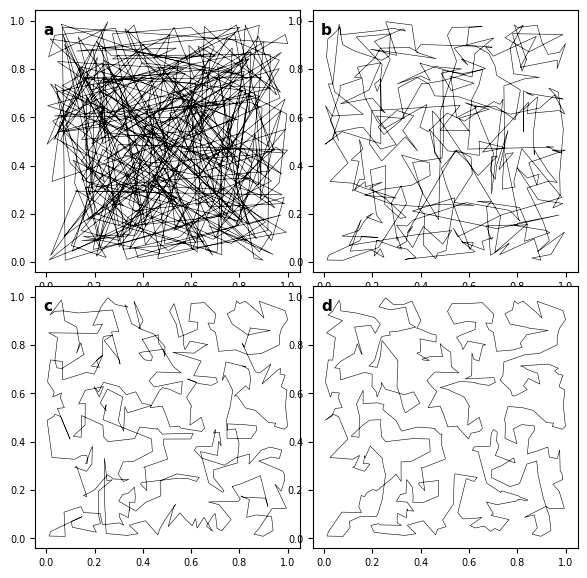


--- linear ---
Final tour length: 35.0579
Panel a: key=0.5, length=194.6862
Panel b: key=0.05, length=53.0260
Panel c: key=0.01, length=36.2506
Panel d: key=final, length=35.0579


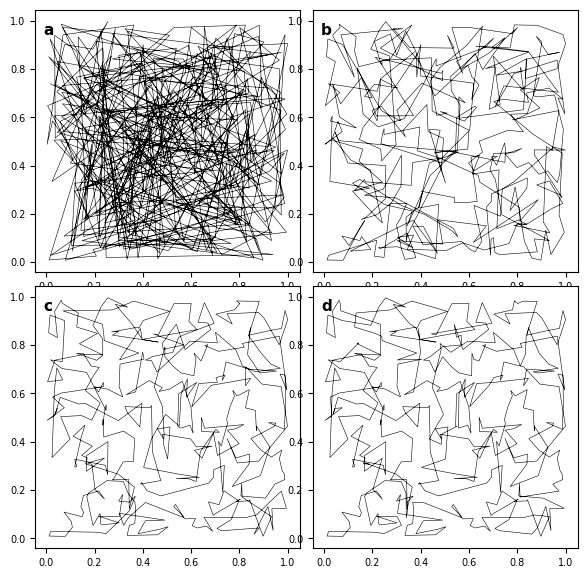


--- logarithmic ---
Final tour length: 24.7214
Panel a: key=0.5, length=184.9549
Panel b: key=0.05, length=45.7892
Panel c: key=0.01, length=26.4807
Panel d: key=final, length=24.7214


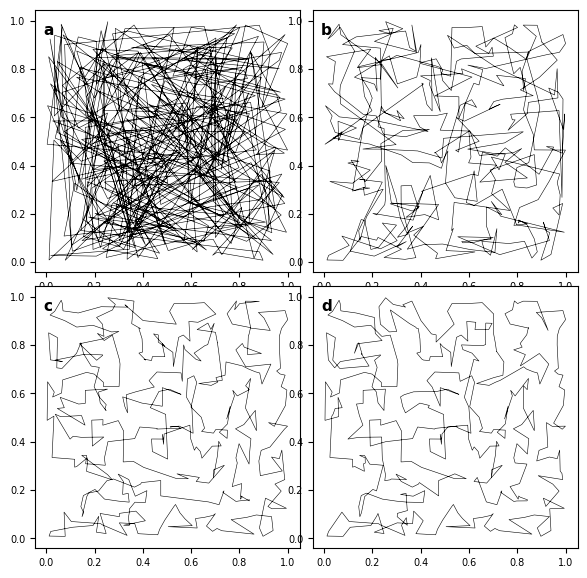

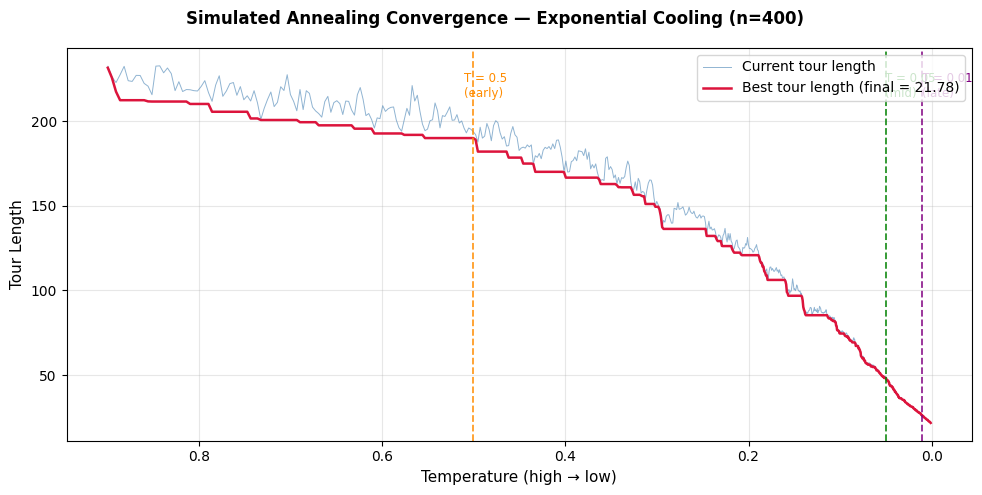

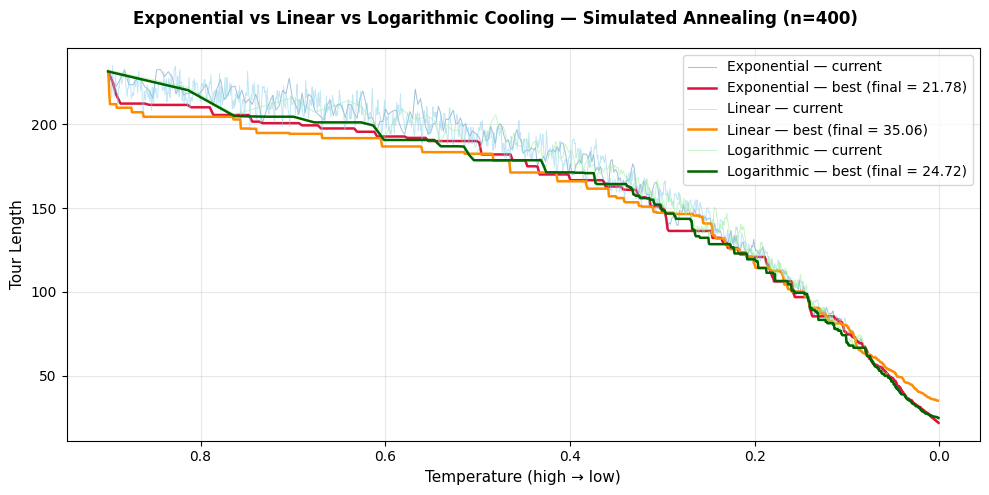

In [ ]:
cities, _ = generate_cities(400, 9, 2)
# cities = load('/content/sample_data/zi929.tsp')
n = len(cities)
dist_matrix = [[0] * n for _ in range(n)]
for i in range(n):
    for j in range(n):
        x1, y1 = cities[i]
        x2, y2 = cities[j]
        dist_matrix[i][j] = abs(cities[j][0] - cities[i][0]) + abs(cities[j][1] - cities[i][1])

start_temp = 0.9
end_temp = 0.001
cooling_rate = 0.995
moves = 400

snapshot = [0.5, 0.05, 0.01]

print('Running simulated annealing')
results = []
for label, cooling in [('Exponential', 'exponential'), ('Linear', 'linear'), ('Logarithmic', 'logarithmic')]:
    best_tour, best_length, saved_tours, temp_history, length_history, best_history = simulated_annealing(dist_matrix, start_temp, end_temp, cooling_rate, cooling, moves, snapshot, 2)

    results.append({'label': label, 'temp_history': temp_history,
                    'length_history': length_history, 'best_history': best_history,
                    'best_length': best_length})

cooling_names = ['exponential', 'linear', 'logarithmic']

for cooling in cooling_names:
    best_tour, best_length, saved_tours, temp_h, len_h, best_h = \
        simulated_annealing(dist_matrix, start_temp, end_temp, cooling_rate,
                            cooling, moves, snapshot, seed=2)

    print(f'\n--- {cooling} ---')
    print(f'Final tour length: {best_length:.4f}')
    plot_tour_snapshots(saved_tours, best_tour, dist_matrix, cities,
                        save_path=f'tsp_snapshots_{cooling}.png')

exp_result = next(r for r in results if r['label'] == 'Exponential')
plot_exponetial(exp_result['temp_history'], exp_result['length_history'],
                 exp_result['best_history'], exp_result['best_length'])

plot_convergence(results)
